In [1]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import HARP_and_age as haa

import pickle
import importlib

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u

from astropy.visualization import quantity_support
quantity_support()

with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)

In [110]:
def get_same_region_file_lists(samesames, all_targets, get_agelists=False, noxrt=False, aiaxrt=False):

    #For the list of lists of region names, make a file list for every separate region
    filelist = []
    if get_agelists:
        agelist=[]
    for s in samesames:
        ss_filelist=[]
        if get_agelists:
            ss_agelist=[]
        #For each key-region combo in the list of instances of this region
        for ss in s:
            #sub-keys in the key
            sks = all_targets[ss.split(' ')[0]]['sub_keys']
            #for each sub-key
            for i in range(0, len(sks)):
                #if the sub-key is the key-region combo we want...
                if sks[i] == ss:
                    #print(ss.split(' ')[0], i)
                    if noxrt:
                        ss_filelist.extend(all_targets[ss.split(' ')[0]]['res_file_dict(s)'][i]['quiet files no_xrt'])
                    elif aiaxrt:
                        ss_filelist.extend(all_targets[ss.split(' ')[0]]['res_file_dict(s)'][i]['quiet files aiaxrt'])
                    else:
                        if len(all_targets[ss.split(' ')[0]]['res_file_dict(s)'][i]['quiet files all-inst-gr-corr']) > 0:
                            ss_filelist.extend(all_targets[ss.split(' ')[0]]['res_file_dict(s)'][i]['quiet files all-inst-gr-corr'])
                        else:
                            ss_filelist.extend(all_targets[ss.split(' ')[0]]['res_file_dict(s)'][i]['quiet files all-inst'])

                        #print(ss)
                        #print(ss_filelist)
                    if get_agelists:
                        #print(ss.split(' ')[0], i)
                        #print(ss, all_targets[ss.split(' ')[0]]['Region Ages'])
                        ss_agelist.append(all_targets[ss.split(' ')[0]]['Region Ages'][i])
                        
        filelist.append(ss_filelist)
        if get_agelists:
            agelist.append(ss_agelist)

    if get_agelists:
        return filelist, agelist
    else:
        return filelist


def make_labels(regids):
    

    arlabs=[]
    for r in regids:
        ss = r[0]
        ars = all_targets[ss.split(' ')[0]]['NOAA_ARID']
        locs = all_targets[ss.split(' ')[0]]['loc']
        if len(locs) == 1:
            arlabs.append(all_targets[ss.split(' ')[0]]['NOAA_ARID'][0])
        else:
            if ss[-1]=='0':
                arlabs.append(all_targets[ss.split(' ')[0]]['NOAA_ARID'][0])
            elif ss[-1]=='1':
                arlabs.append(all_targets[ss.split(' ')[0]]['NOAA_ARID'][1])

    #Making labels
    labs=[]
    #For each region
    for r in regids:
        #print(r)
        lab=''
        first=0
        # if 1 == 2:
        #     numstr = ' '
        # else:
        numstr = '' #' #'+str(int(r[0][-1])+1)
        #For each day it was observed
        for ss in r:
            #If it's the first day...
            if first == 0:
                #If the first character is 0 (aka day of month < 10)
                if ss[0] == '0':
                    #'#'+str(int(ss[-1])+1)+
                    lab=lab+ss[1:9]+numstr+' '
                else: 
                    #
                    lab=lab+ss[0:9]+numstr+' '
                first=1
                #print(lab)
            else:
                if ss[0] == '0':
                    lab=ss[1:2]+','+lab
                else:    
                    lab=ss[0:2]+','+lab
    
        labs.append(lab)
    
    plotlabs = [labs[i]+arlabs[i] for i in range(0, len(labs))]

    return plotlabs



def check_contig(time_intervals):
    """
    Return true if the list of start,stop times is contiguous, False if not 
    (plus list of gaps).
    """
    #Check if the quiescent times are contiguous for this region. If not, save a list of the gaps.
    contiguous=True
    gaps=[]
    intervals=[]
    int_inds=[]
    starter=0
    #For each entry in the list of time intervals
    for i in range(0,len(time_intervals)-1):
            #If the end of this interval doesn't match the beginning of the next.
            if not time_intervals[i][1]==time_intervals[i+1][0]:
                #print('GAP!', times[i:i+3])
                contiguous=False
                gaps.append(time_intervals[i:i+2])
                intervals.append(time_intervals[starter:i+1])
                int_inds.append((starter, i+1))
                starter=i+1
                if i+1==len(time_intervals)-1:
                    intervals.append(time_intervals[-1])
                    int_inds.append((starter,len(time_intervals)))
    
    if contiguous:
        intervals.append(time_intervals)
        int_inds.append((starter, len(time_intervals)))
    
    return contiguous, gaps, intervals, int_inds

Need to fix issue where if the last time interval is its own separate contiguous interval, it's not included (and possibly general handling of last value?) 



In [111]:
#Make EM > 10 MK needed arrays etc

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
grf = data['ghost ray flags']
filelist = get_same_region_file_lists(samesames, all_targets)


#Factor to adjust integrated EM values
area_i = 100**2
area_m = np.pi*150**2
#print(area_i, area_m)
factor = area_m/area_i
#factor=1


allgood=0
region_above10s=[]
region_totaltime=[]
region_totalvals=[]
times_per=[]
contigs=[]
all_times=[]
all_intervals=[]

region_int_above10s=[]

for i in range(0, len(filelist)):
    gf = filelist[i]

    vals = []
    above10s_ = []
    totaltime = 0
    times=[]
    durs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        time = data['time_interval']
        dur = (time[1]-time[0]).to(u.s).value
        durs.append(dur)
        times.append(time)
        above10s = data['above_10MK']
        #print(f_)
        #print(above10s)
        above10s_.append(above10s[0])
        vals.append([dur*above10s[0]])
        totaltime+=dur

    contiguous, gaps, intervals, int_inds = check_contig(times)
    print(samesames[i])
    print(contiguous)
    print(int_inds)
    print(intervals)
    print(times)
    print('')
    if vals:
        region_int_above10s_=[]
        for ii in int_inds:
            indx = np.arange(ii[0],ii[1])
            int_vals = np.array(vals)[indx]
            int_a10s = np.array(above10s_)[indx]
            int_durs = np.array(durs)[indx]
            region_int_above10s_.append([np.sum(int_vals)/np.sum(int_durs)*factor, np.min(int_a10s)*factor, np.max(int_a10s)*factor])

        region_int_above10s.append(region_int_above10s_)
        
        region_above10s.append([np.sum(vals)/totaltime*factor, np.min(above10s_)*factor, np.max(above10s_)*factor])
        region_totaltime.append(totaltime)
        region_totalvals.append(len(vals))
        times_per.append([np.min(times), np.max(times)])
        all_times.append(times)
        all_intervals.append(intervals)
        contigs.append(contiguous)

    else:
        region_int_above10s.append([])
        region_above10s.append([0, 0, 0])
        region_totaltime.append(0)
        region_totalvals.append(0)
        times_per.append([])
        all_times.append([])
        all_intervals.append([])
        contigs.append(False)
    



outputs = [region_above10s, region_totaltime, region_totalvals, times_per, all_times, all_intervals, contigs]


['01-nov-14_1 region_0']
True
[(0, 2)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 41, 55)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 41, 55)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]
[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 41, 55)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 41, 55)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]

['01-nov-14_1 region_1']
True
[(0, 1)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]
[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]

['11-dec-14 region_0']
True
[(0, 1)]
[[<Time object: scale='utc' f

In [95]:
vals

[[1.0579198020294107e+23],
 [6.012567281035553e+22],
 [4.160985545521859e+22],
 [7.503752497911571e+22],
 [7.175558195460709e+22],
 [5.492952157327374e+22],
 [1.3273395437821973e+23],
 [1.3068755093712262e+23],
 [8.78593860115874e+22],
 [1.1177794583497478e+23],
 [1.1509817145076781e+23],
 [1.1706227193845422e+23],
 [6.8292240554083226e+22],
 [6.661394986446438e+22],
 [4.45408783229357e+22],
 [9.24347145539641e+22],
 [8.584857648301984e+22]]

In [97]:
np.sum(vals)

1.4621997773051056e+24

In [96]:
above10s_

[1.0075426685994653e+21,
 1.0020945468392625e+21,
 5.201231931901927e+20,
 3.3350011101829674e+20,
 5.5196601503544784e+20,
 3.7882428671223195e+20,
 2.042060836588179e+21,
 1.7425006791615853e+21,
 9.762154001287004e+20,
 1.2419771759442348e+21,
 9.207853716061163e+20,
 1.9510378656409107e+21,
 9.75603436486929e+20,
 1.110232497741077e+21,
 9.897972960652941e+20,
 1.8486942910792293e+21,
 1.1446476864402319e+21]

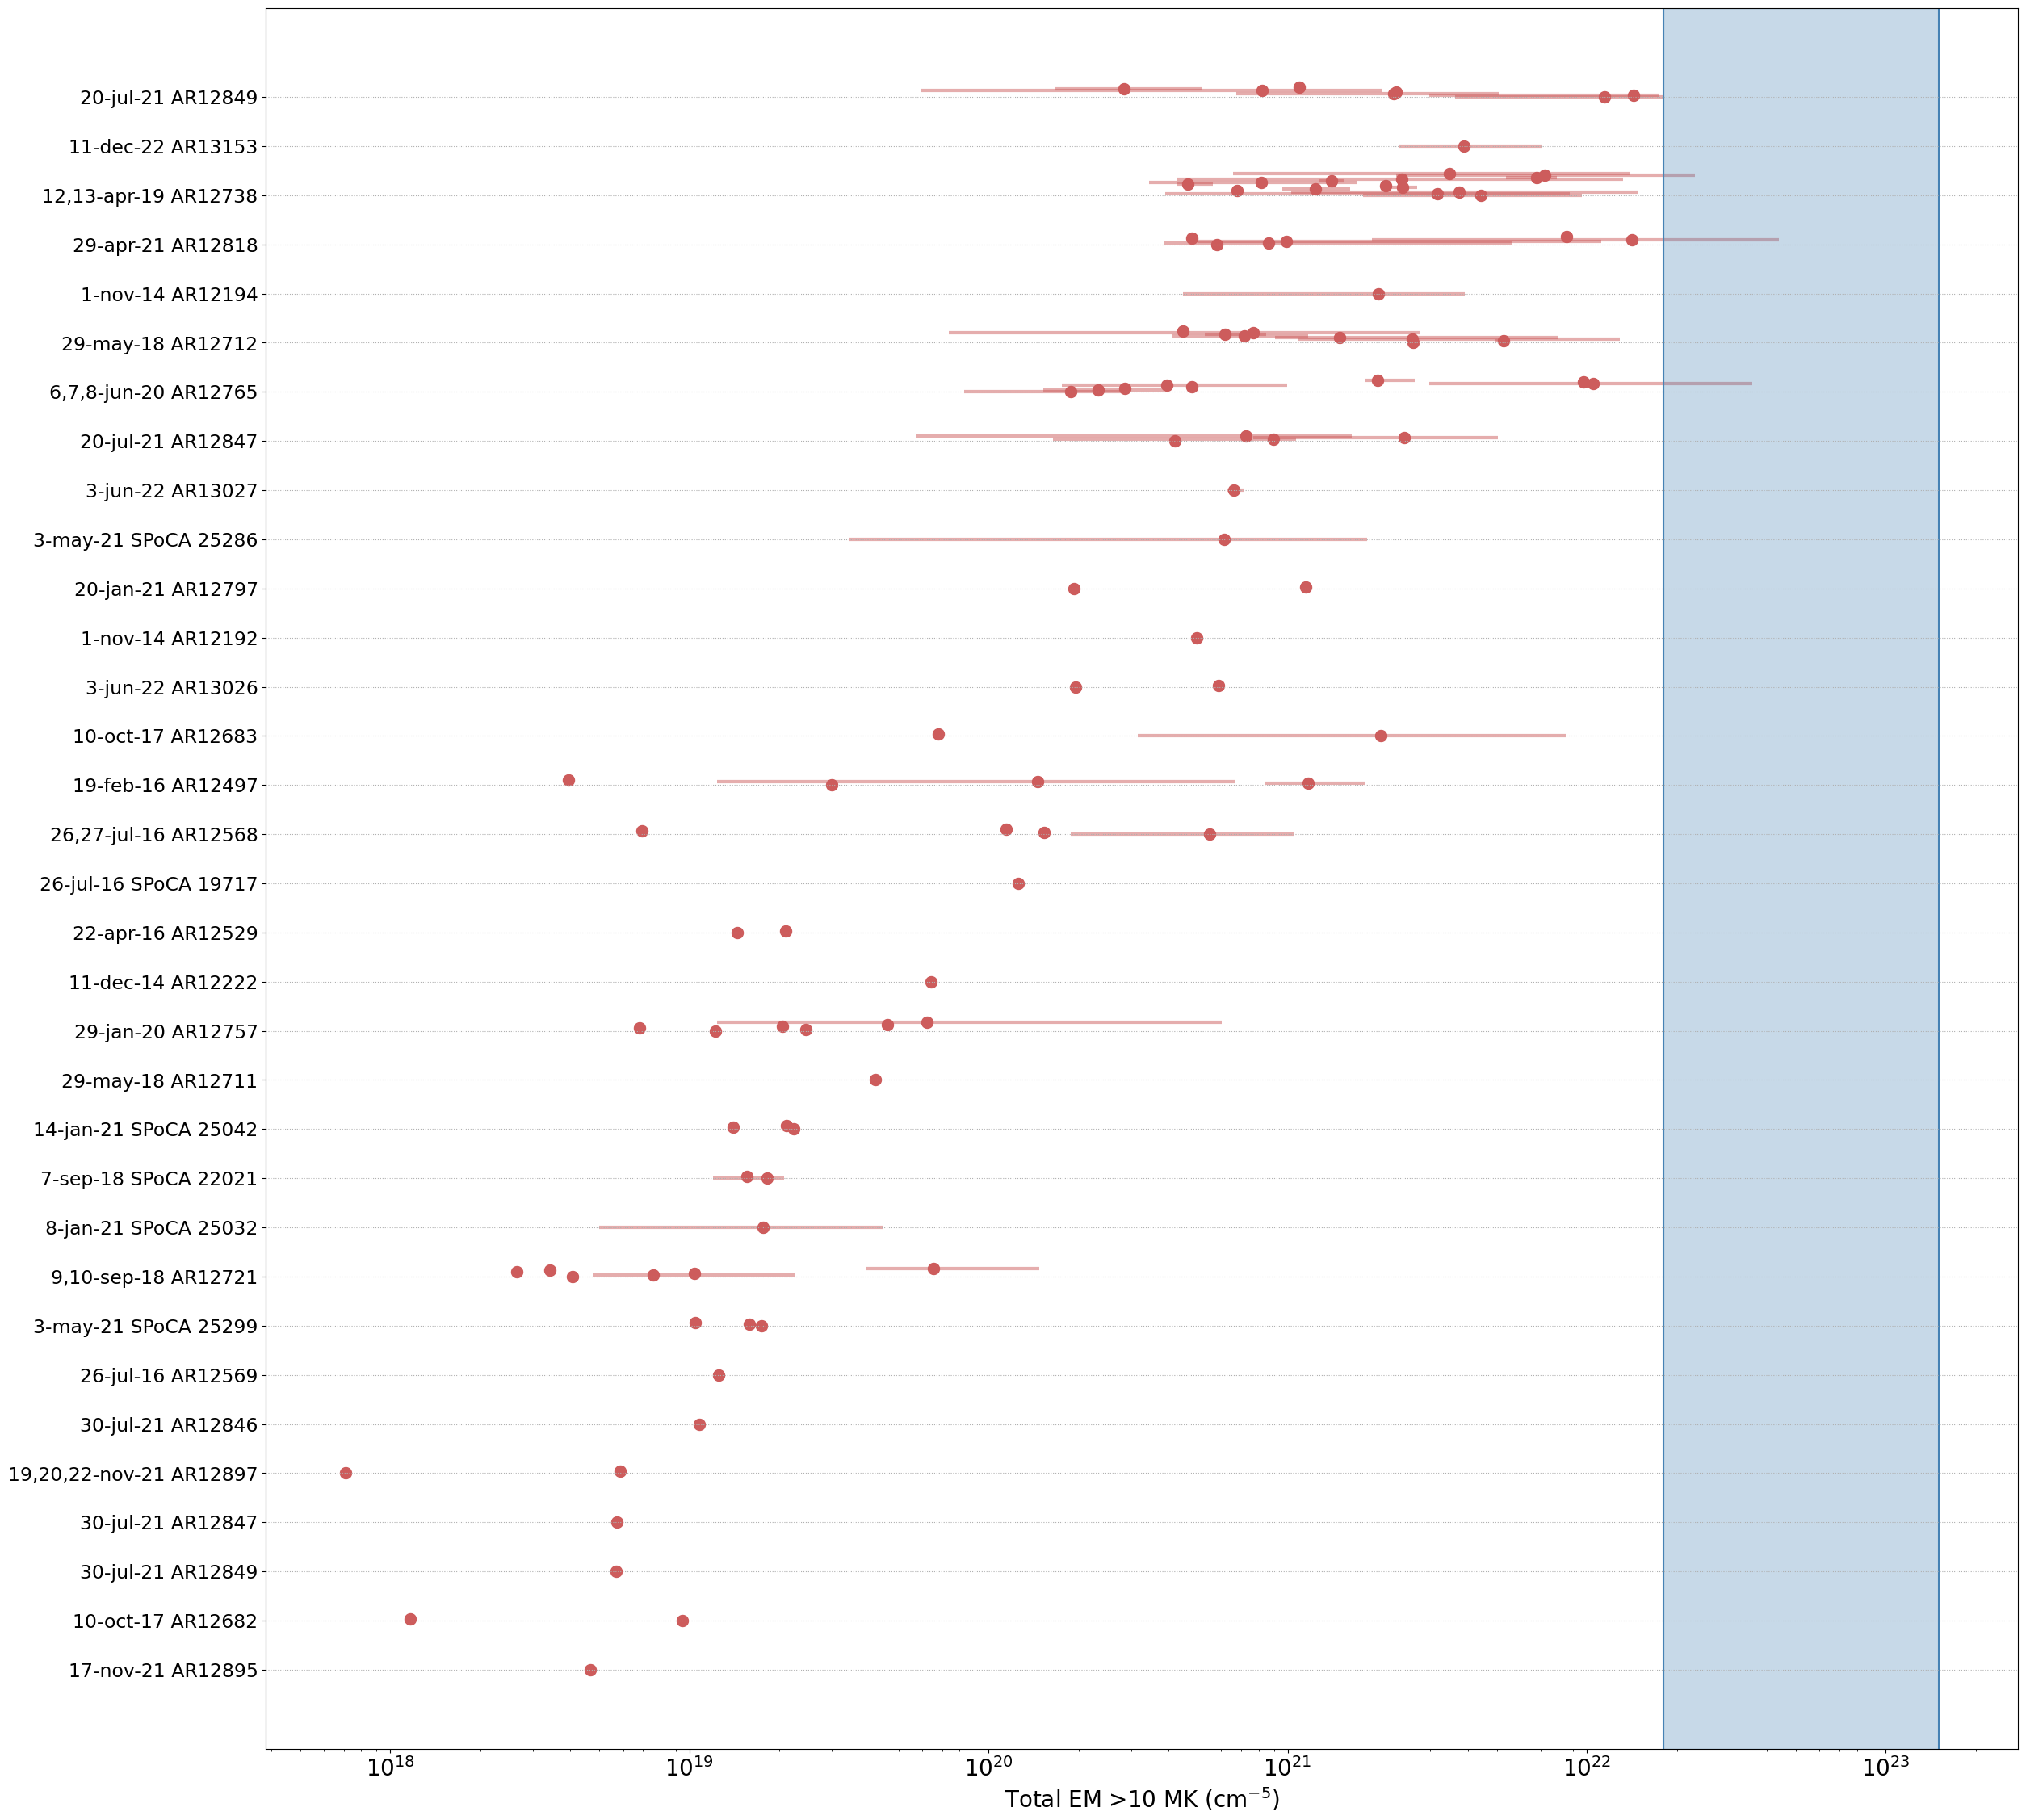

In [112]:
order = np.argsort(np.array(region_above10s)[:,0])
regids = [samesames[i] for i in order]

plotlabs = make_labels(regids)
region_int_above10s_sort = [region_int_above10s[i] for i in order]


fig, ax = plt.subplots(1, 1, figsize=(28,28))

val=0
for rr in region_int_above10s_sort:
    regionabove10s=rr
    xerrl = (np.array(regionabove10s)[:,0]- np.array(regionabove10s)[:,1])
    xerrl[np.where(xerrl < 1e10)] = 0.0
    xerrh = (np.array(regionabove10s)[:,2] - np.array(regionabove10s)[:,0])
    xerrh[np.where(xerrh < 1e10)] = 0.0
    
    xerr = [xerrl, xerrh]

    vert=np.arange(0, (len(rr)))*0.1+val
    if len(vert) ==0:
        vert=np.array([val])
    ax.errorbar(np.array(regionabove10s)[:,0], vert, 
                xerr=xerr,
               linestyle='', marker='o', linewidth=3, alpha=0.5, markersize=10, color='indianred',zorder=0)
    ax.errorbar(np.array(regionabove10s)[:,0], vert, 
               linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', zorder=1)#, label='New Regions', zorder=1)
    val+=3

ax.set_yticks(np.arange(0, val, 3)) #[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=17)
ax.set_xscale('log')
ax.grid(axis = 'y', linestyle='dotted')
plt.xticks(fontsize=20)
ax.set_xlabel('Total EM >10 MK ('+(u.cm**(-5)).to_string('latex_inline')+')', fontsize=20)
ax.axvline(1.8e22, color='steelblue', zorder=0)
ax.axvline(1.5e23, color='steelblue', zorder=0)
ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)

In [77]:
val
#np.arange(0, vals, 2)

[[1.0579198020294107e+23],
 [6.012567281035553e+22],
 [4.160985545521859e+22],
 [7.503752497911571e+22],
 [7.175558195460709e+22],
 [5.492952157327374e+22],
 [1.3273395437821973e+23],
 [1.3068755093712262e+23],
 [8.78593860115874e+22],
 [1.1177794583497478e+23],
 [1.1509817145076781e+23],
 [1.1706227193845422e+23],
 [6.8292240554083226e+22],
 [6.661394986446438e+22],
 [4.45408783229357e+22],
 [9.24347145539641e+22],
 [8.584857648301984e+22]]

In [64]:
np.arange(val, val+0.1*(len(rr)-1), 0.1)

array([4.])

In [34]:
thing = all_intervals[5]

for tt in thing:
    print(tt)

[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 27, 0, 13)
 datetime.datetime(2016, 7, 27, 0, 18, 50)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 27, 0, 18, 50)
 datetime.datetime(2016, 7, 27, 0, 23)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 27, 0, 23)
 datetime.datetime(2016, 7, 27, 0, 25, 10)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 27, 0, 25, 10)
 datetime.datetime(2016, 7, 27, 0, 27)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 27, 0, 27)
 datetime.datetime(2016, 7, 27, 0, 29, 5)]>]
[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 7, 26, 20, 11, 35)
 datetime.datetime(2016, 7, 26, 20, 23, 20)]>]
[[<Time object: scale='utc' format='datetime' value=2016-07-26 20:59:35>, <Time object: scale='utc' format='datetime' value=2016-07-26 21:55:25>]]


In [45]:
range(0, 2)

range(0, 2)

[[1.25555564e+21]
 [1.15717552e+22]]
[[1.56578466e+21]
 [1.89658424e+21]]
[[0.]
 [0.]]

[ 0  1  2  6  7 11 17 21 25 26 27 28 31]
[ 0  3  4  5  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 29 30 31 32]
[ 3  4  5  8  9 10 12 13 14 15 16 18 19 20 22 23 24 29 30 32]


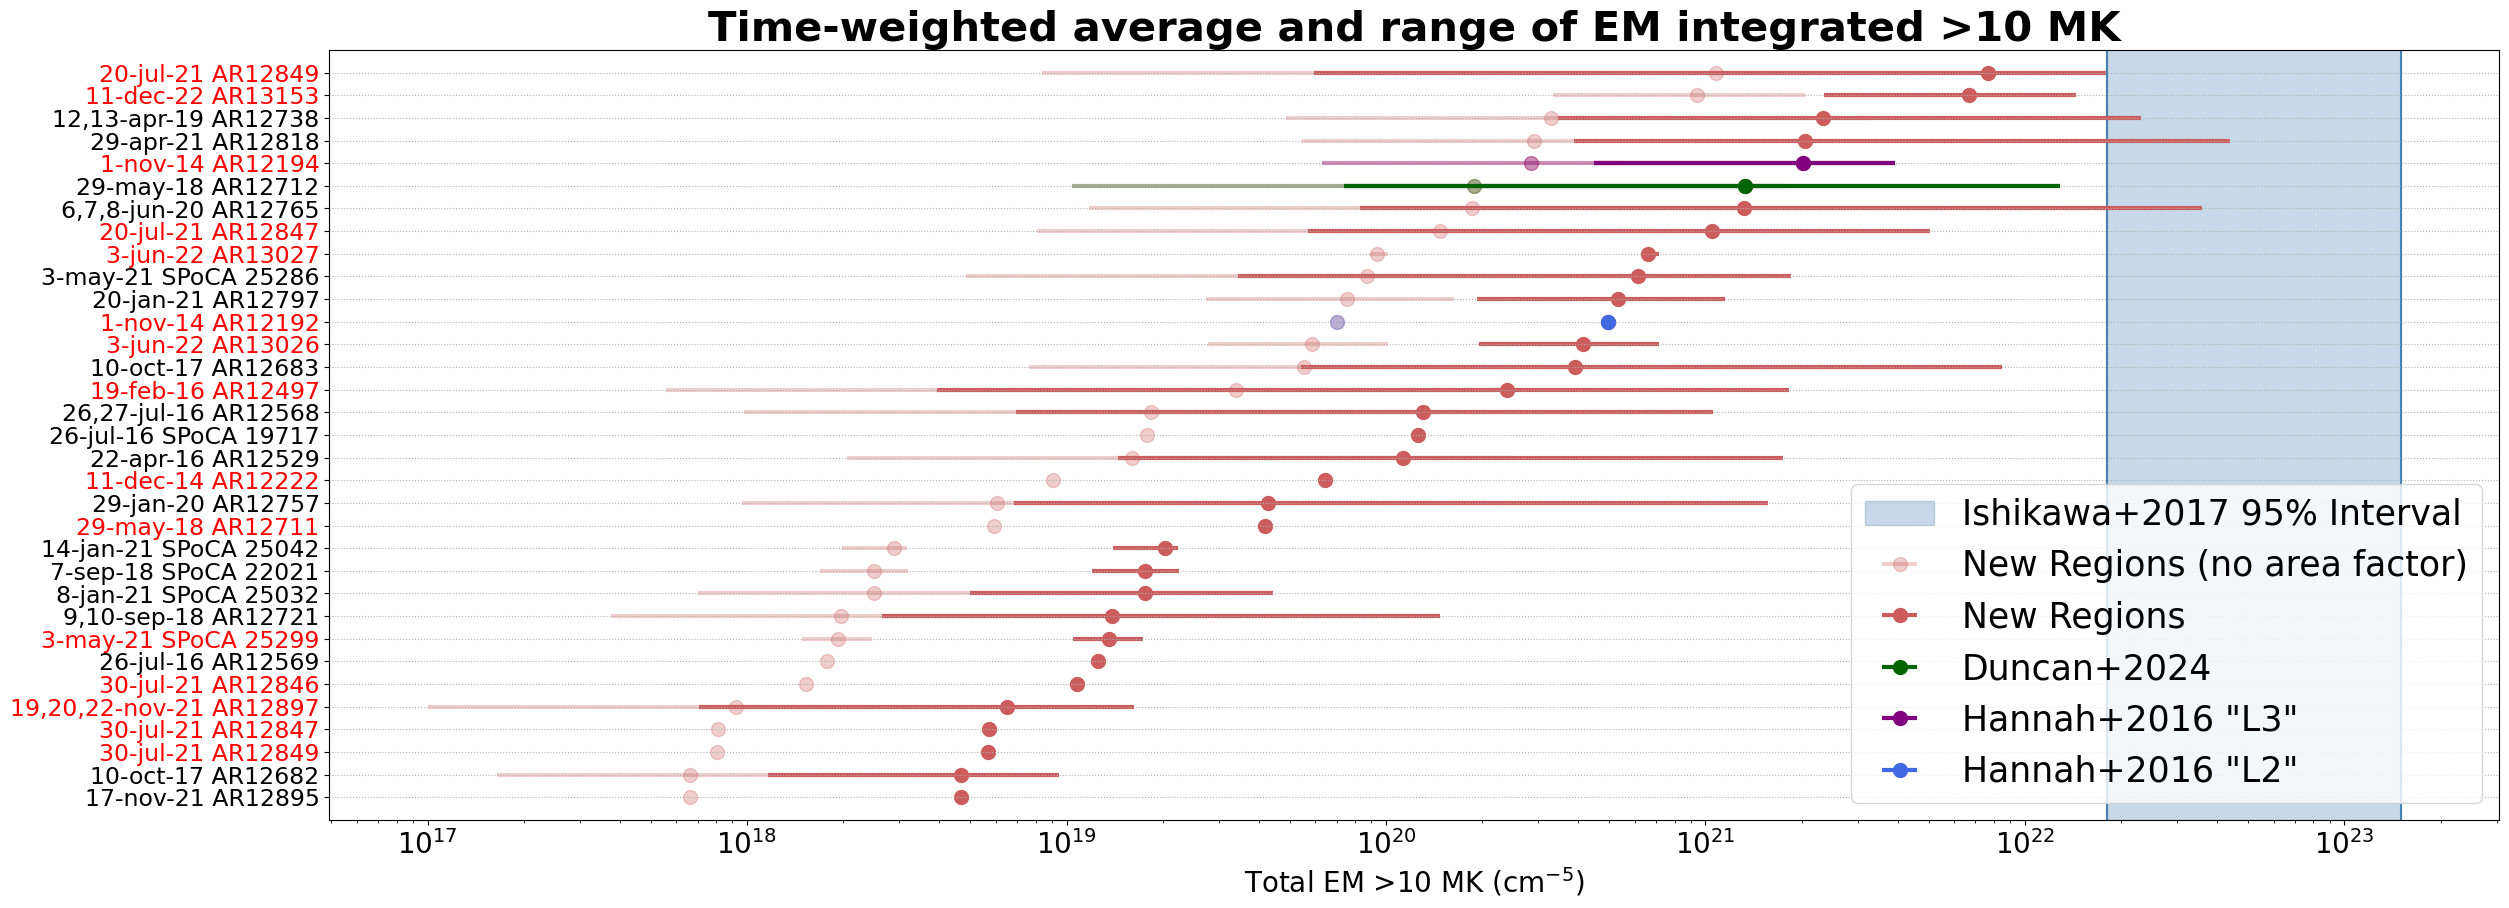

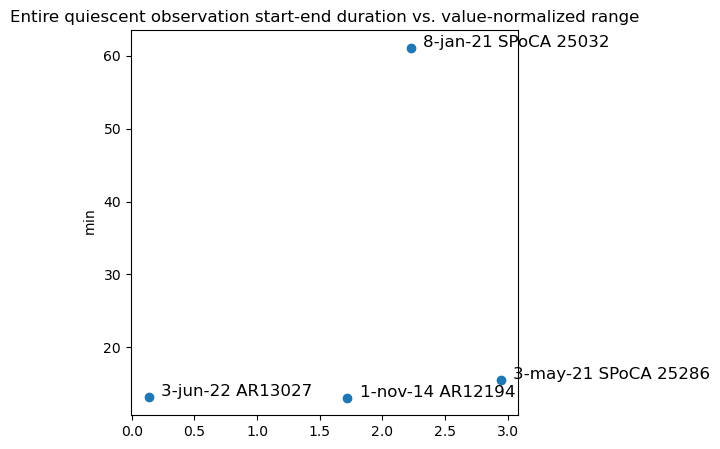

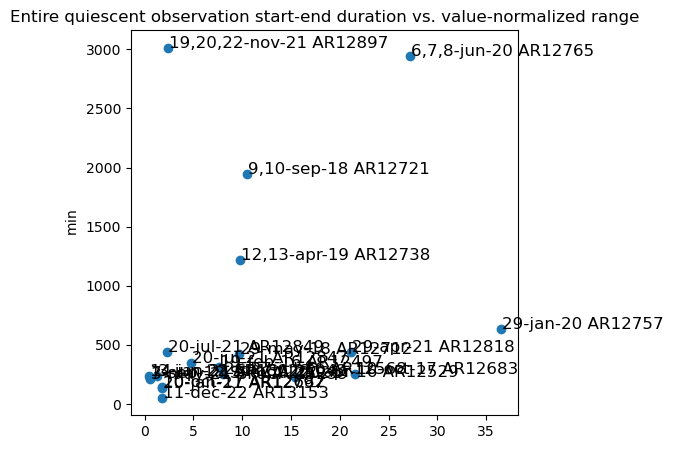

In [92]:
order = np.argsort(np.array(region_above10s)[:,0])
regids = [samesames[i] for i in order]
grf = [grf[i] for i in order]

ghost_ticks = np.where(grf)[0]

plotlabs = make_labels(regids)

#print('')
#print(len(labs))
#print(len(order))

region_time_hr = np.array((region_totaltime*u.s).to(u.hr))
#print(region_time_hr[order])


fig, ax = plt.subplots(1, 1, figsize=(28,10))


xerrl = (np.array(region_above10s)[:,0][order]/factor - np.array(region_above10s)[:,1][order]/factor)
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order]/factor - np.array(region_above10s)[:,0][order]/factor)
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr_nf = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order]/factor, np.arange(0, len(filelist), 1), 
            xerr=xerr_nf,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', 
            label='New Regions (no area factor)', alpha=0.3, zorder=0)

xerrl = (np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order])
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order], np.arange(0, len(filelist), 1), 
            xerr=xerr,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', label='New Regions', zorder=1)



oneerr = np.zeros((2,1))

ginds = [27, 28, 21]
colors = ['darkgreen', 'purple', 'royalblue']
labels = ['Duncan+2024', 'Hannah+2016 "L3"', 'Hannah+2016 "L2"']
gc=0
for gind in ginds:
    oneerr[0] = xerr[0][gind]
    oneerr[1] = xerr[1][gind]
    
    print(oneerr)
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind]/factor, np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr/factor,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, alpha=0.3, zorder=2) #, s=140)
    
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind], np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, label=labels[gc], zorder=2) #, s=140)

    gc+=1



fntsz=25
ax.set_xscale('log')
ax.axvline(1.8e22, color='steelblue', zorder=0)
ax.axvline(1.5e23, color='steelblue', zorder=0)
ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)
ax.set_yticks(np.arange(0, len(filelist))) #[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=17) #[2:]
plt.xticks(fontsize=20)
ax.set_xlabel('Total EM >10 MK ('+(u.cm**(-5)).to_string('latex_inline')+')', fontsize=20)
ax.grid(axis = 'y', linestyle='dotted')
ax.legend(loc='lower right', fontsize=fntsz)
ax.set_ylim([-1,len(filelist)])
#ax.set_xlim([4e17,2e24])
ax.set_title('Time-weighted average and range of EM integrated >10 MK', fontsize=30, fontweight='bold')
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

plt.savefig('per_region_above10_new_postghost_postshut_ghostcorr.png', dpi=300)





def plot_range_v_dur(comp_cases, region_above10s, region_totalvals):

    ranges = np.array(region_above10s)[:,2] - np.array(region_above10s)[:,1]
    int_number = np.array(region_totalvals)
    normranges = ranges/np.array(region_above10s)[:,0]
    
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    ranges=ranges[comp_cases]
    normranges=normranges[comp_cases]
    int_number=int_number[comp_cases]
    plotlabs = make_labels(samesames)
    sss=np.array(plotlabs)[comp_cases]
    
    TOT_DUR = [(time[1]-time[0]).to(u.min).value for time in times_per]*u.min
    
    TOT_DUR = TOT_DUR[comp_cases]
    
    ax.scatter(normranges, TOT_DUR)
    for i, label in enumerate(sss):
        plt.text(normranges[i] + 0.1, TOT_DUR[i] + 0.1*u.min, label, fontsize=12)
    #ax.set_yscale('log')
    #ax.set_xscale('log')   
    ax.set_title('Entire quiescent observation start-end duration vs. value-normalized range')

ctg_cases = np.where(contigs)[0]
print(ctg_cases)

int_number = np.array(region_totalvals)
comp_cases = np.where(int_number > 1)[0]
print(comp_cases)

both = np.where(np.logical_and(int_number > 1, contigs))[0]
plot_range_v_dur(both, region_above10s, region_totalvals)

nonconts = np.where(np.array(contigs) == False)[0]
print(nonconts)
plot_range_v_dur(nonconts, region_above10s, region_totalvals)
